In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.io import read_image
from torch.nn import functional as F 

from pathlib import Path
from torch.optim import AdamW
from torch.amp import GradScaler, autocast

from PIL import Image

import kagglehub
import os

from torchvision.transforms import functional as TF

import random

In [2]:
def download():
    path = kagglehub.dataset_download('tawsifurrahman/covid19-radiography-database')
    print(f'data installed on {path}')
    return path

In [3]:
path = 'C:\\Users\\panika\\.cache\\kagglehub\\datasets\\tawsifurrahman\\covid19-radiography-database\\versions\\5' # download()
print(path)

C:\Users\panika\.cache\kagglehub\datasets\tawsifurrahman\covid19-radiography-database\versions\5


In [4]:
def analyze(path, sep='/'):
    path = path + sep + 'COVID-19_Radiography_Dataset'
    variants = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

    i = 0
    total = 0
    for variant in variants:
        vpath = path + sep + variant + sep + 'images'
        count = len(os.listdir(vpath))
        total += count
        print(f'Вариантов картинок c типом {variant}: {count}')
        
        i += 1

    print(f'Общее количество картинок {total}')

In [5]:
analyze(path, '\\')

Вариантов картинок c типом COVID: 3476
Вариантов картинок c типом Lung_Opacity: 5773
Вариантов картинок c типом Normal: 10085
Вариантов картинок c типом Viral Pneumonia: 1343
Общее количество картинок 20677


In [87]:
def get_paired_paths(root_path, sep='/'):
    root_path = root_path + sep + 'COVID-19_Radiography_Dataset'
    variants = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
    valid_pairs = []
    count = 0
    for var in variants:
        img_dir = Path(root_path) / var / 'images'
        mask_dir = Path(root_path) / var / 'masks'
            
        masks = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])
        
        for mask_name in masks:
            img_path = img_dir / mask_name
            mask_path = mask_dir / mask_name
            
            if img_path.exists():
                valid_pairs.append((str(img_path), str(mask_path), var))
            else:
                print(f"{mask_name}")
                count += 1
                
    print(f"Итого валидных пар для обучения: {len(valid_pairs)}")
    print(count)
    return valid_pairs

In [88]:
pairs = get_paired_paths(path, '\\')

COVID-1015.png
COVID-102.png
COVID-1051.png
COVID-1086.png
COVID-1096.png
COVID-1117.png
COVID-1120.png
COVID-1132.png
COVID-1137.png
COVID-1145.png
COVID-1172.png
COVID-1179.png
COVID-1184.png
COVID-1193.png
COVID-1210.png
COVID-1212.png
COVID-1225.png
COVID-1232.png
COVID-1244.png
COVID-125.png
COVID-1279.png
COVID-131.png
COVID-1315.png
COVID-1318.png
COVID-1321.png
COVID-1322.png
COVID-1327.png
COVID-1332.png
COVID-1333.png
COVID-1357.png
COVID-1365.png
COVID-1368.png
COVID-1379.png
COVID-1389.png
COVID-1407.png
COVID-1420.png
COVID-1434.png
COVID-1435.png
COVID-1436.png
COVID-1444.png
COVID-1447.png
COVID-1450.png
COVID-1463.png
COVID-1464.png
COVID-1466.png
COVID-1476.png
COVID-1487.png
COVID-1500.png
COVID-1512.png
COVID-1523.png
COVID-1526.png
COVID-1540.png
COVID-1541.png
COVID-1556.png
COVID-1562.png
COVID-1566.png
COVID-1591.png
COVID-1595.png
COVID-1600.png
COVID-1605.png
COVID-1625.png
COVID-1627.png
COVID-1645.png
COVID-1654.png
COVID-1656.png
COVID-1673.png
COVID-1675.pn

In [8]:
class XRayMaskDataset(Dataset):
    def __init__(self, pairs, transform=None):
        """
        pairs: список кортежей (path_to_image, path_to_mask, class_name)
        """
        self.pairs = pairs
        self.transform = transform
        self.class_map = {'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path, class_name = self.pairs[idx]
        
        # Загрузка в Grayscale (L)
        image = Image.open(img_path).convert('L')
        mask = Image.open(mask_path).convert('L')
        
        if self.transform:
            seed = torch.initial_seed()
            torch.manual_seed(seed)
            image = self.transform(image)
            
            torch.manual_seed(seed)
            mask = self.transform(mask)

        mask = (mask > 0).float()
        
        class_id = torch.tensor(self.class_map[class_name], dtype=torch.long)
        
        return image, mask, class_id

In [9]:
def get_dataloader(pairs, batch_size=32, num_workers=4):
    """
    pairs: список кортежей от функции get_paired_paths
    """
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    dataset = XRayMaskDataset(pairs, transform=transform)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True,
        drop_last=True
    )

    return loader

In [10]:
loader = get_dataloader(pairs)

In [11]:
batch = next(iter(loader))
images, masks, labels = batch

print(f"Формат изображений: {images.shape}")
print(f"Формат масок: {masks.shape}")
print(f"Формат меток: {labels.shape}")

print(torch.cat([images, masks], dim=1).shape)

Формат изображений: torch.Size([32, 1, 128, 128])
Формат масок: torch.Size([32, 1, 128, 128])
Формат меток: torch.Size([32])
torch.Size([32, 2, 128, 128])


In [12]:
class AttentionBlock(nn.Module):
    def __init__(self, channels, n_heads=1):
        super().__init__()
        self.channels = channels
        self.norm = nn.GroupNorm(32, channels)
        self.inner_dim = channels // 4

        self.q = nn.Conv2d(channels, self.inner_dim, kernel_size=1, bias=False)
        self.k = nn.Conv2d(channels, self.inner_dim, kernel_size=1, bias=False)
        self.v = nn.Conv2d(channels, channels, kernel_size=1, bias=False)

        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1, bias=False)
        self.scale = self.inner_dim ** (-0.5)

    def forward(self, x):
        b, c, h, w = x.shape
        n = h * w
        h_ = self.norm(x)
        
        q = self.q(h_).view(b, self.inner_dim, n)
        k = self.k(h_).view(b, self.inner_dim, n)
        v = self.v(h_).view(b, c, n)

        attn = torch.einsum('b d i, b d j -> b i j', q, k)
        attn = torch.softmax(self.scale * attn, dim=-1)

        out = torch.einsum('b i j, b c j -> b c i', attn, v)

        out = out.view(b, c, h, w)
        return x + self.proj_out(out)

In [13]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, groups=32):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.time_mlp = nn.Linear(time_dim, out_channels)

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.activation = F.silu

    def forward(self, x, time_embedding):
        h = self.norm1(x)
        h = self.activation(h)
        h = self.conv1(h)
                                  
        bias = self.time_mlp(self.activation(time_embedding))
        h = h + bias[:, :, None, None]

        h = self.norm2(h)
        h = self.activation(h)
        h = self.conv2(h)

        return h + self.shortcut(x)

In [14]:
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_dim)
        self.down = nn.Conv2d(out_channels, out_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x, time_embedding):
        x = self.res(x, time_embedding)
        return x, self.down(x)

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_dim)
        self.conv = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x, skip, time_embedding):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.cat([x, skip], dim=1)
        x = self.res(x, time_embedding)
        return self.conv(x)

In [15]:
class Unet128(nn.Module):
    def __init__(self, in_channels=2, out_channels=1, time_dim=256, num_classes=4):
        super().__init__()
        self.time_dim = time_dim
        
        self.class_emb = nn.Embedding(num_classes, time_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.init_conv = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)

        self.down1 = DownBlock(64, 128, time_dim)
        self.down2 = DownBlock(128, 256, time_dim)
        self.attn2 = AttentionBlock(256)
        self.down3 = DownBlock(256, 512, time_dim)
        self.attn3 = AttentionBlock(512)
        self.down4 = DownBlock(512, 512, time_dim)

        self.res_mid1 = ResidualBlock(512, 512, time_dim)
        self.attn_mid = AttentionBlock(512)
        self.res_mid2 = ResidualBlock(512, 512, time_dim)

        self.up1 = UpBlock(1024, 512, time_dim)
        self.up2 = UpBlock(1024, 256, time_dim)
        self.up3 = UpBlock(512, 128, time_dim)
        self.up4 = UpBlock(256, 64, time_dim)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def pos_encoding(self, t, channels):
        inv_freq = 1.0 / (10000 ** (torch.arange(0, channels, 2).float().to(t.device) / channels))
        t = t.view(-1, 1)  # (batch_size, 1)
        pos_enc_a = torch.sin(t * inv_freq)   # broadcasting
        pos_enc_b = torch.cos(t * inv_freq)
        return torch.cat([pos_enc_a, pos_enc_b], dim=-1)

    def forward(self, x, mask, y, t):
        x = torch.cat([x, mask], dim=1)
        x = self.init_conv(x)

        t_emb = self.pos_encoding(t, self.time_dim)
        t_emb = self.time_mlp(t_emb)
        c_emb = self.class_emb(y)
        context = t_emb + c_emb

        s1, x = self.down1(x, context)
        s2, x = self.down2(x, context)
        x = self.attn2(x)
        s3, x = self.down3(x, context)
        x = self.attn3(x)
        s4, x = self.down4(x, context)

        # 4. Bottleneck
        x = self.res_mid1(x, context)
        x = self.attn_mid(x)
        x = self.res_mid2(x, context)

        x = self.up1(x, s4, context)
        x = self.up2(x, s3, context)
        x = self.up3(x, s2, context)
        x = self.up4(x, s1, context)

        return self.final_conv(x)

In [16]:
def get_cosine_schedule(timesteps, s=0.008):
    """
    Косинусное расписание для бета-коэффициентов.
    Возвращает тензор длиной timesteps.
    """
    # 1. Генерируем сетку t от 0 до T (всего T+1 точка)
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps)
    
    # 2. Вычисляем альфа_кумпрод (f(t) в статье)
    # Формула: f(t) = cos(((t/T + s) / (1 + s)) * pi/2)^2
    alphas_cumprod = torch.cos(((t / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    
    # 3. Нормализуем, чтобы в начале было 1.0 (делим на f(0))
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    
    # 4. Вычисляем беты из отношения кумпродов: beta_t = 1 - (alpha_cumprod_t / alpha_cumprod_{t-1})
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    
    # 5. Ограничиваем беты сверху, чтобы избежать слишком больших значений (обычно 0.999)
    # и снизу, чтобы не было нулей
    return torch.clamp(betas, 0.0001, 0.9999)

In [84]:
name = 'unet128_checkpoint.pth'
# name = 'unet128_checkpoint_ema.pth'
model = Unet128()
# optimizer = torch.optim.Adam(model.parameters())
checkpoint = torch.load(f'../models/v92/{name}', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
avg_loss = checkpoint['loss']

print(f"Resumed from epoch {epoch} with loss {avg_loss} {name}")

Resumed from epoch 196 with loss 0.0027715325162345227 unet128_checkpoint.pth


In [55]:
trash = []
with open('trash.txt', 'r', encoding='utf-8') as f:
    trash = f.read().splitlines()

In [56]:
@torch.no_grad()
def sample_from_mask(model, mask_path, label_id, alphas, alphas_cumprod, betas, device):
    T = len(alphas)
    mask_pil = Image.open(mask_path).convert('L')
    mask_pil = TF.resize(mask_pil, (128, 128), interpolation=TF.InterpolationMode.NEAREST)
    mask = TF.to_tensor(mask_pil).to(device).unsqueeze(0) 
    mask = (mask > 0.5).float()
    
    y = torch.tensor([label_id], device=device).long()
    x = torch.randn((1, 1, 128, 128), device=device)
    
    for i in reversed(range(0, 1000)):
        t = torch.tensor([i], device=device).long()

        with torch.amp.autocast('cuda'):
            epsilon_pred = model(x, mask, y, t)
        
        a = alphas[i]
        a_cp = alphas_cumprod[i]
        b = betas[i]
        
        z = torch.randn_like(x) if i > 0 else 0
            
        coeff = (1 - a) / torch.sqrt(1 - a_cp + 1e-7)
        mu = (1 / torch.sqrt(a)) * (x - coeff * epsilon_pred)
        sigma = torch.sqrt(b)
        
        x = mu + sigma * z
        
        x = x.clamp(-1,1)
        
    return x

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

T = 1000
betas = get_cosine_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

mask_path = path + '\\COVID-19_Radiography_Dataset\\COVID\\masks\\COVID-45.png'
mask_path1 = path + '\\COVID-19_Radiography_Dataset\\COVID\\masks\\COVID-46.png'
mask_path2 = path + '\\COVID-19_Radiography_Dataset\\COVID\\masks\\COVID-47.png'
mask_path3 = path + '\\COVID-19_Radiography_Dataset\\COVID\\masks\\COVID-48.png'

In [74]:
generated_tensor = sample_from_mask(
    model=model,
    mask_path=mask_path,
    label_id=3,
    alphas=alphas,
    alphas_cumprod=alphas_cumprod,
    betas=betas,
    device=device
)

In [75]:
generated_tensor1 = sample_from_mask(
    model=model,
    mask_path=mask_path1,
    label_id=3,
    alphas=alphas,
    alphas_cumprod=alphas_cumprod,
    betas=betas,
    device=device
)

In [76]:
generated_tensor2 = sample_from_mask(
    model=model,
    mask_path=mask_path2,
    label_id=3,
    alphas=alphas,
    alphas_cumprod=alphas_cumprod,
    betas=betas,
    device=device
)

In [77]:
generated_tensor3 = sample_from_mask(
    model=model,
    mask_path=mask_path3,
    label_id=3,
    alphas=alphas,
    alphas_cumprod=alphas_cumprod,
    betas=betas,
    device=device
)

In [100]:
gen_img0 = generated_tensor.view(128, 128).to('cpu')
gen_img1 = generated_tensor1.view(128, 128).to('cpu')
gen_img2 = generated_tensor2.view(128, 128).to('cpu')
gen_img3 = generated_tensor3.view(128, 128).to('cpu')

Text(0.5, 1.0, 'bone')

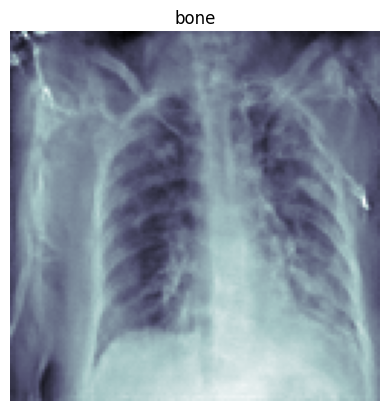

In [106]:
plt.imshow(gen_img, cmap='bone')
plt.axis('off')

In [79]:
def foo(path, nums):
    path = path + '\\COVID-19_Radiography_Dataset\\NORMAL\\images\\'
    images = []
    for num in nums:
        img_path = path + f'Normal-{num}.png'
        img = Image.open(img_path).convert('L')
        img_resized = img.resize((128, 128), Image.Resampling.LANCZOS)
        
        transform = transforms.ToTensor()
        img_tensor = transform(img_resized).squeeze(0)
        images.append(img_tensor)
    return images

In [101]:
# true_images = foo(path, [9271, 2415, 945])
images = []
images.append(gen_img0)
images.append(gen_img1)
images.append(gen_img2)
images.append(gen_img3)
# random.shuffle(images)

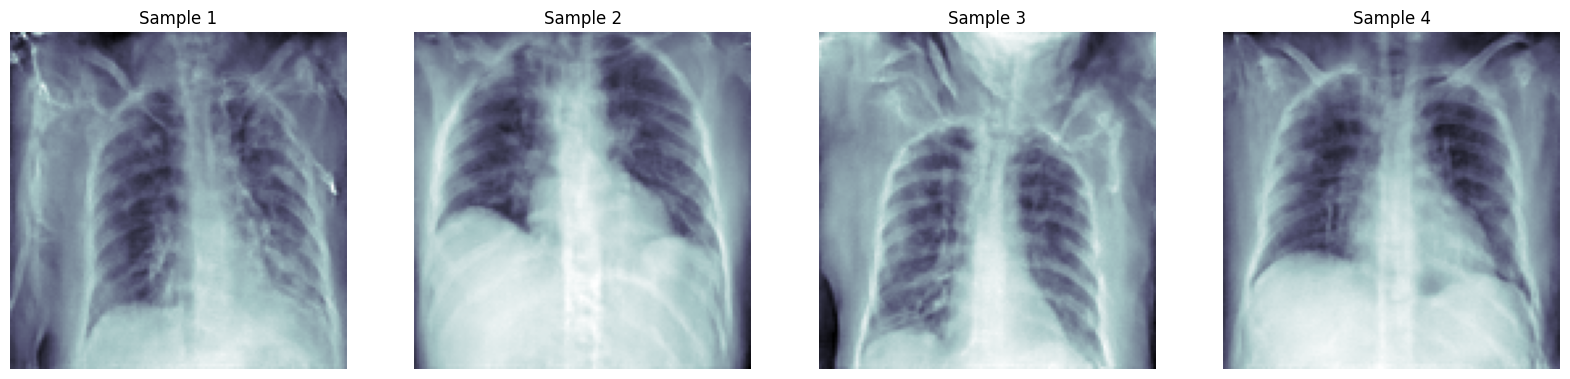

In [103]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    img = images[i]
    axes[i].imshow(img, cmap='bone')
    axes[i].axis('off')
    axes[i].set_title(f"Sample {i+1}")
plt.savefig('xrays0.png')

In [ ]:
def cos():
    t = 1000
    betas, alphas_cumprod = cosine_beta_schedule(T)
    metrics(alphas_cumprod, 'Косинусная')

In [ ]:
def lin():
    t = 1000
    beta = torch.linspace(1e-4, 0.02, T + 1)
    alphas = 1.0 - beta
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    metrics(alphas_cumprod, 'Линейная')

In [ ]:
lin()
cos()

In [ ]:
def get_cosine_schedule(timesteps, s=0.008):
    """
    Косинусное расписание для бета-коэффициентов.
    Возвращает тензор длиной timesteps.
    """
    # 1. Генерируем сетку t от 0 до T (всего T+1 точка)
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps)
    
    # 2. Вычисляем альфа_кумпрод (f(t) в статье)
    # Формула: f(t) = cos(((t/T + s) / (1 + s)) * pi/2)^2
    alphas_cumprod = torch.cos(((t / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    
    # 3. Нормализуем, чтобы в начале было 1.0 (делим на f(0))
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    
    # 4. Вычисляем беты из отношения кумпродов: beta_t = 1 - (alpha_cumprod_t / alpha_cumprod_{t-1})
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    
    # 5. Ограничиваем беты сверху, чтобы избежать слишком больших значений (обычно 0.999)
    # и снизу, чтобы не было нулей
    return torch.clamp(betas, 0.0001, 0.9999)

# Пример использования:
T = 1000
betas = get_cosine_schedule(T)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

print(f"Длина alphas_cumprod: {len(betas)}") # Будет ровно 1000
print(f"Min alphas_cumprod: {alphas_cumprod[0]}")
print(f"Max alphas_cumprod: {alphas_cumprod[-1]}")

In [ ]:
# checkpoint_data = {
#     'epoch': epoch,
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'scaler_state_dict': scaler.state_dict(),
#     'loss': avg_loss,
#     'config': {'size': 128, 'T': T, 'min_snr_gamma': 5.0}
# }

In [ ]:
# def train_epoch(model, dataloader, optimizer, scaler, alphas_cumprod, device):
#     model.train()
#     total_loss = 0
#     T = len(alphas_cumprod)

#     for i, (x0, masks, labels) in enumerate(dataloader):
#         x0 = x0.to(device)
#         masks = masks.to(device)
#         labels = labels.to(device)
#         batch_size = x0.shape[0]

#         t = torch.randint(0, T, (batch_size,), device=device).long()
#         noise = torch.randn_like(x0)

#         sqrt_alphas_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
#         sqrt_one_minus_alphas_t = torch.sqrt(1 - alphas_cumprod[t]).view(-1, 1, 1, 1)
#         xt = sqrt_alphas_t * x0 + sqrt_one_minus_alphas_t * noise

#         with torch.cuda.amp.autocast():
#             snr = alphas_cumprod[t] / (1 - alphas_cumprod[t] + 1e-7)
#             mse_loss_weights = torch.clamp(snr, max=5.0) / snr
#             mse_loss_weights = mse_loss_weights.view(-1, 1, 1, 1)

#             predicted_noise = model(xt, masks, labels, t)
            
#             loss_map = F.mse_loss(predicted_noise, noise, reduction='none')
#             loss = (loss_map * mse_loss_weights).mean()

#         optimizer.zero_grad()
#         scaler.scale(loss).backward()
        
#         scaler.unscale_(optimizer)
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
#         scaler.step(optimizer)
#         scaler.update()

#         total_loss += loss.item()
        
#     return total_loss / len(dataloader)

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# checkpoint_path = "unet128_checkpoint.pth"

# beta = torch.linspace(1e-4, 0.02, T).to(device)
# alphas = 1.0 - beta
# alphas_cumprod = torch.cumprod(alphas, dim=0)

# model = Unet128(in_channels=2, out_channels=1, time_dim=256, num_classes=4).to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
# scaler = GradScaler()

# start_epoch = 0

# if os.path.exists(checkpoint_path):
#     print(f"Загрузка чекпоинта: {checkpoint_path}")
#     checkpoint = torch.load(checkpoint_path, map_location=device)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     scaler.load_state_dict(checkpoint['scaler_state_dict'])
#     start_epoch = checkpoint['epoch'] + 1
#     print(f"Возобновление с эпохи {start_epoch}")

# num_epochs = 70

# for epoch in range(start_epoch, num_epochs):
#     print(f"\nЭпоха {epoch+1}/{num_epochs}")
    
#     avg_loss = train_epoch(
#         model, 
#         train_loader, 
#         optimizer, 
#         scaler, 
#         alphas_cumprod, 
#         device
#     )
    
#     print(f"Средний Loss: {avg_loss:.6f}")

#     checkpoint_data = {
#         'epoch': epoch,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'scaler_state_dict': scaler.state_dict(),
#         'loss': avg_loss,
#         'config': {'size': 128, 'T': T, 'min_snr_gamma': 5.0}
#     }
#     torch.save(checkpoint_data, checkpoint_path)

#     if epoch % 10 == 0:
#         torch.save(checkpoint_data, f"unet256_xray_epoch_{epoch}.pth")
    
#     if (epoch + 1) % 1 == 0:
#         model.eval()
#         with torch.no_grad():
#             test_batch = next(iter(train_loader))
#             test_mask = test_batch[1][0:1].to(device)
#             test_label = test_batch[2][0:1].to(device)
            
#             print(f"Эпоха {epoch+1} завершена. Модель сохранена.")